In [2]:
# =========================================
# BLOCK 1 — Load Dataset & Basic Structure
# =========================================

import pandas as pd
import numpy as np

DATA_PATH = "/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_synthetic_forecasting_dataset_monthly_36m.xlsx"

df = pd.read_excel(DATA_PATH, sheet_name="FG_Demand_Long")

df["month"] = pd.to_datetime(df["month"])
df = df.sort_values(["fg_code","month"])

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nDate Range:", df["month"].min(), "→", df["month"].max())
print("Number of SKUs:", df["fg_code"].nunique())
print("Number of Months:", df["month"].nunique())

df.head()

Shape: (3708, 5)
Columns: ['month', 'fg_code', 'fg_name', 'fg_category', 'demand_units']

Date Range: 2023-02-01 00:00:00 → 2026-01-01 00:00:00
Number of SKUs: 103
Number of Months: 36


,month,fg_code,fg_name,fg_category,demand_units
0,2023-02-01,FG001,Baby Soap 50g,Soap,27456
103,2023-03-01,FG001,Baby Soap 50g,Soap,27316
206,2023-04-01,FG001,Baby Soap 50g,Soap,25194
309,2023-05-01,FG001,Baby Soap 50g,Soap,22610
412,2023-06-01,FG001,Baby Soap 50g,Soap,22763


In [3]:
# =========================================
# BLOCK 2 — Create Complete Monthly Calendar
# =========================================

all_months = pd.date_range(df["month"].min(), df["month"].max(), freq="MS")
skus = df["fg_code"].unique()

full = (
    pd.MultiIndex.from_product([skus, all_months], names=["fg_code","month"])
    .to_frame(index=False)
    .merge(df, on=["fg_code","month"], how="left")
)

missing_count = full["demand_units"].isna().sum()
print("Missing demand values before fill:", missing_count)

# Fill missing with 0 (correct for warehouse sales data)
full["demand_units"] = full["demand_units"].fillna(0)

print("Final shape:", full.shape)

Missing demand values before fill: 0
Final shape: (3708, 5)


In [4]:
# =========================================
# BLOCK 3 — Per-SKU Statistics
# =========================================

sku_stats = full.groupby("fg_code")["demand_units"].agg(
    mean="mean",
    std="std",
    min="min",
    max="max",
    total="sum"
).reset_index()

sku_stats["cv"] = sku_stats["std"] / (sku_stats["mean"] + 1e-9)
sku_stats["zero_ratio"] = full.groupby("fg_code")["demand_units"].apply(lambda x: (x==0).mean()).values

sku_stats.describe()

,mean,std,min,max,total,cv,zero_ratio
count,103.000000,103.000000,103.000000,103.000000,1.030000e+02,103.000000,103.0
mean,29995.533711,3633.188717,22656.388350,38333.087379,1.079839e+06,0.130721,0.0
std,18389.598147,2179.181271,14448.348328,23251.371796,6.620255e+05,0.040147,0.0
min,4125.333333,673.624777,2266.000000,6369.000000,1.485120e+05,0.063705,0.0
25%,16935.861111,1839.790447,12699.500000,20256.500000,6.096910e+05,0.108850,0.0
50%,26967.250000,3223.655986,21003.000000,35651.000000,9.708210e+05,0.130738,0.0
75%,40335.847222,4829.836299,29571.000000,50304.500000,1.452090e+06,0.144489,0.0
max,80146.861111,11187.166884,60873.000000,108530.000000,2.885287e+06,0.294333,0.0


In [5]:
# =========================================
# BLOCK 4 — SKU Segmentation
# =========================================

def segment(row):
    if row["zero_ratio"] > 0.3:
        return "Intermittent"
    elif row["cv"] > 1.0:
        return "Erratic"
    elif row["cv"] < 0.5:
        return "Smooth"
    else:
        return "Moderate"

sku_stats["segment"] = sku_stats.apply(segment, axis=1)

sku_stats["segment"].value_counts()

segment
Smooth    103
Name: count, dtype: int64

Global skewness: 0.7754458894979624


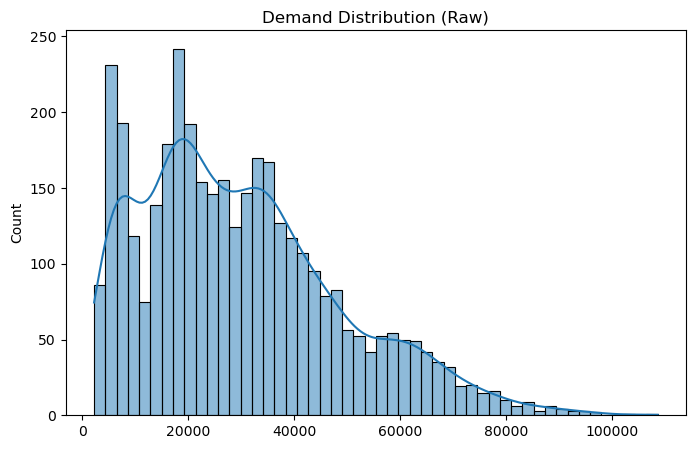

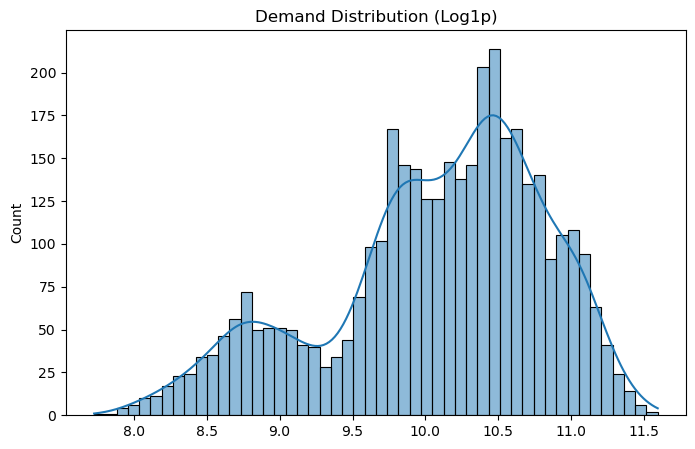

In [6]:
# =========================================
# BLOCK 5 — Skewness & Distribution
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

all_values = full["demand_units"].values

print("Global skewness:", skew(all_values))

plt.figure(figsize=(8,5))
sns.histplot(all_values, bins=50, kde=True)
plt.title("Demand Distribution (Raw)")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(np.log1p(all_values), bins=50, kde=True)
plt.title("Demand Distribution (Log1p)")
plt.show()


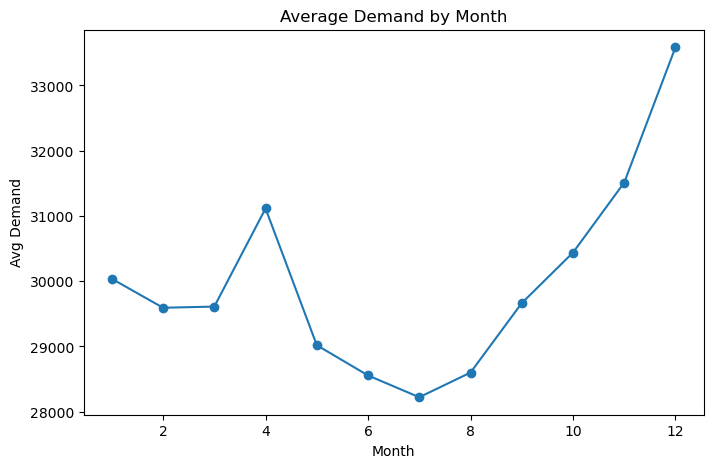

In [7]:
# =========================================
# BLOCK 6 — Seasonality Check
# =========================================

full["month_num"] = full["month"].dt.month

monthly_avg = full.groupby("month_num")["demand_units"].mean()

plt.figure(figsize=(8,5))
monthly_avg.plot(marker="o")
plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Avg Demand")
plt.show()

<Figure size 800x500 with 0 Axes>

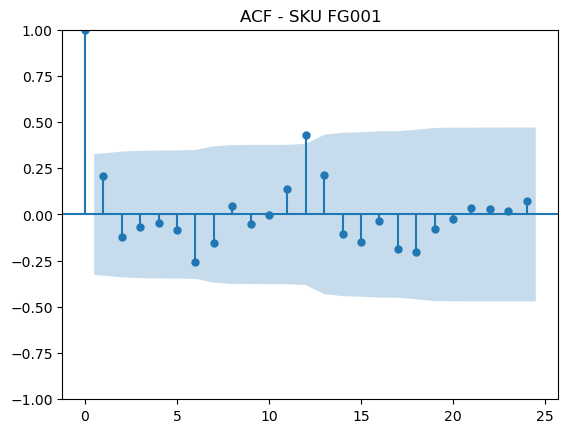

In [8]:
# =========================================
# BLOCK 7 — Autocorrelation (Sample SKU)
# =========================================

from statsmodels.graphics.tsaplots import plot_acf

sample_sku = full["fg_code"].unique()[0]
series = full[full["fg_code"] == sample_sku]["demand_units"]

plt.figure(figsize=(8,5))
plot_acf(series, lags=24)
plt.title(f"ACF - SKU {sample_sku}")
plt.show()

In [9]:
# =========================================
# BLOCK 8 — Outlier Detection
# =========================================

def detect_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = max(0, q1 - 1.5 * iqr)
    return ((group > upper) | (group < lower)).sum()

outlier_counts = full.groupby("fg_code")["demand_units"].apply(detect_outliers)

print("Total SKUs with outliers:", (outlier_counts > 0).sum())

Total SKUs with outliers: 38


In [10]:
# =========================================
# BLOCK 9 — Data Quality Checks
# =========================================

print("Negative values:", (full["demand_units"] < 0).sum())
print("Null values:", full.isnull().sum().sum())

# Check if any SKU has completely zero demand
zero_skus = sku_stats[sku_stats["total"] == 0]["fg_code"]
print("SKUs with zero total demand:", len(zero_skus))

Negative values: 0
Null values: 0
SKUs with zero total demand: 0


In [11]:
# =========================================
# BLOCK 10 — Final Clean Dataset
# =========================================

# Remove fully zero SKUs
clean_skus = sku_stats[sku_stats["total"] > 0]["fg_code"]

clean_df = full[full["fg_code"].isin(clean_skus)].copy()

print("Final modeling shape:", clean_df.shape)

Final modeling shape: (3708, 6)
